In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [2]:
# Load data
try:
    data = pd.read_csv('patient_data.csv')
except FileNotFoundError:
    print("Error: patient_data.csv not found.")
    exit()

# **Data Cleaning Steps:**

### **1) Handling Missing Values**

In [3]:
data.isnull().sum()

,0
C,0
Age,0
History,0
Patient,0
TakeMedication,0
Severity,0
BreathShortness,0
VisualChanges,0
NoseBleeding,0
Whendiagnoused,0


### **2) Data Type Corrections: Rename Coloumn 'C' to 'Gender" for Clarity**

In [4]:
data.rename(columns={'C': "Gender"}, inplace=True)

In [5]:
data.isnull().sum()

,0
Gender,0
Age,0
History,0
Patient,0
TakeMedication,0
Severity,0
BreathShortness,0
VisualChanges,0
NoseBleeding,0
Whendiagnoused,0


### **3) Inconsistency Corrections: Fixed spelling errors and standardized categorical values**

In [6]:
# -----------------------------
# Remove extra spaces from all string columns
# -----------------------------
data = data.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

print("===== BEFORE CORRECTION =====")

print("\nTakeMedication value counts:")
print(data['TakeMedication'].value_counts())

print("\nNoseBleeding value counts:")
print(data['NoseBleeding'].value_counts())

print("\nSystolic value counts:")
print(data['Systolic'].value_counts())

print("\nDiastolic value counts:")
print(data['Diastolic'].value_counts())

print("\nStages value counts:")
print(data['Stages'].value_counts())


# 2) Standardize Categorical Values (Handling inconsistencies in CSV)
data['TakeMedication'] = data['TakeMedication'].replace(['Yes ', ' yes', 'YES'], 'Yes')
data['TakeMedication'] = data['TakeMedication'].replace(['No ', ' no', 'NO'], 'No')

data['NoseBleeding'] = data['NoseBleeding'].replace(['Yes ', ' yes', 'YES'], 'Yes')
data['NoseBleeding'] = data['NoseBleeding'].replace(['No ', ' no', 'NO'], 'No')

data['Severity'] = data['Severity'].replace(['Sever', 'sever'], 'Severe')

data['Stages'] = data['Stages'].replace({
    'HYPERTENSION (Stage-2).': 'HYPERTENSION (Stage-2)',
    'HYPERTENSION (Stage-2) ': 'HYPERTENSION (Stage-2)',
    'HYPERTENSIVE CRISI': 'HYPERTENSIVE CRISIS',
    'HYPERTENSIVE CRISIS ': 'HYPERTENSIVE CRISIS'
})

print("\n===== AFTER CORRECTION =====")

print("\nTakeMedication value counts:")
print(data['TakeMedication'].value_counts())

print("\nNoseBleeding value counts:")
print(data['NoseBleeding'].value_counts())

print("\nSystolic value counts:")
print(data['Systolic'].value_counts())

print("\nDiastolic value counts:")
print(data['Diastolic'].value_counts())

print("\nStages value counts:")
print(data['Stages'].value_counts())

===== BEFORE CORRECTION =====

TakeMedication value counts:
TakeMedication
Yes    1081
No      744
Name: count, dtype: int64

NoseBleeding value counts:
NoseBleeding
No     1380
Yes     445
Name: count, dtype: int64

Systolic value counts:
Systolic
111 - 120    1008
121- 130      481
130+          236
121 - 130      96
100+            4
Name: count, dtype: int64

Diastolic value counts:
Diastolic
81 - 90     708
91 - 100    540
70 - 80     336
100+        237
130+          4
Name: count, dtype: int64

Stages value counts:
Stages
HYPERTENSION (Stage-1)     648
HYPERTENSION (Stage-2)     599
NORMAL                     336
HYPERTENSIVE CRISIS        240
HYPERTENSION (Stage-2).      1
HYPERTENSIVE CRISI           1
Name: count, dtype: int64

===== AFTER CORRECTION =====

TakeMedication value counts:
TakeMedication
Yes    1081
No      744
Name: count, dtype: int64

NoseBleeding value counts:
NoseBleeding
No     1380
Yes     445
Name: count, dtype: int64

Systolic value counts:
Systolic
111 

### **4) Duplicate Removal: Removed 477 duplicate records from the original 1825 records**

In [7]:
print(data.duplicated().sum())

477


In [8]:
data.drop_duplicates(inplace=True)

# **Label Encoding Applied:**

Gender: Male=0, Female=1

Binary features: No=0, Yes=1

Age groups: 18-34=1, 35-50=2, 51-64=3, 65+=4

Severity: Mild=0, Moderate=1, Severe=2

Blood pressure ranges: Encoded as ordinal values

Target stages: Normal=0, Stage-1=1, Stage-2=2, Crisis=3

In [9]:
nominal_features=['Gender', 'History', 'Patient', 'TakeMedication','BreathShortness', 'VisualChanges', 'NoseBleeding', 'ControlledDiet',]
ordinal_features=[f for f in data.columns if f not in nominal_features]
ordinal_features.remove('Stages')
print(nominal_features)
print(ordinal_features)

['Gender', 'History', 'Patient', 'TakeMedication', 'BreathShortness', 'VisualChanges', 'NoseBleeding', 'ControlledDiet']
['Age', 'Severity', 'Whendiagnoused', 'Systolic', 'Diastolic']


## **1. Gender Distribution**
  A count plot and pie chart were used to visualize the distribution of genders in the dataset.
 The count plot (Figure 1) revealed that the dataset contains an almost equal representation of male and female patients, ensuring balanced demographic coverage for analysis.
 The pie chart (Figure 2) further confirmed this observation, showing near 50–50 distribution between genders. This balance minimizes gender bias during model training and interpretation.

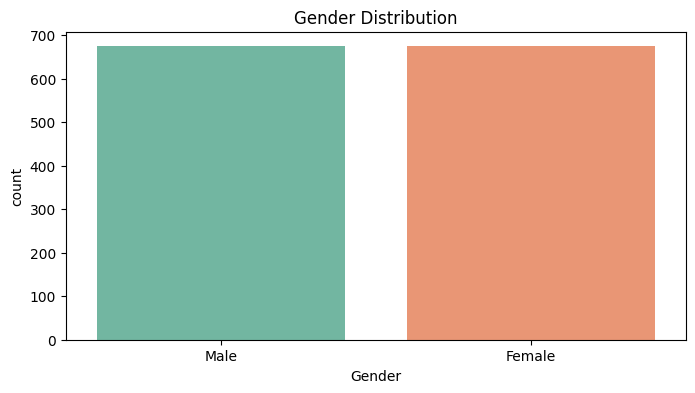

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure 1: Count Plot
plt.figure(figsize=(8,4))
sns.countplot(data=data, x="Gender", hue="Gender", palette="Set2", legend=False)
plt.title("Gender Distribution")
plt.show()

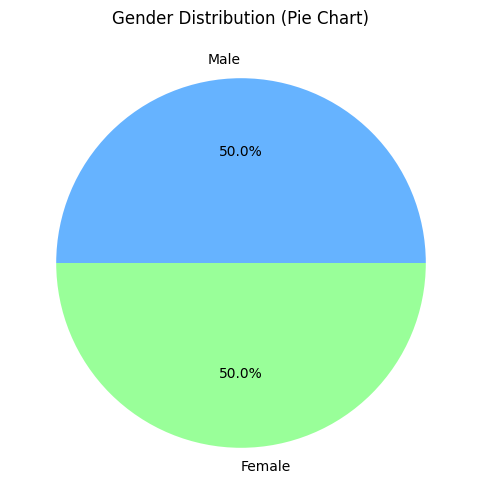

In [11]:
# Figure 2: Pie Chart
plt.figure(figsize=(6,6))
data['Gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#99ff99'], startangle=0)
plt.title("Gender Distribution (Pie Chart)")
plt.ylabel('')
plt.show()

# **2. Hypertension Stages Distribution**

A bar chartwas used to display the count of patients across different hypertension stages.
 The plot showed that Stage-1 hypertension is the most prevalent category, representing the majority of patients in the dataset. Stages 2 and 3 were less frequent, indicating fewer cases of severe hypertension. This insight suggests that most patients in the dataset are in the early phase of the condition, making early intervention analysis feasible.

/tmp/ipykernel_14478/1695634405.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="Stages", palette="coolwarm")


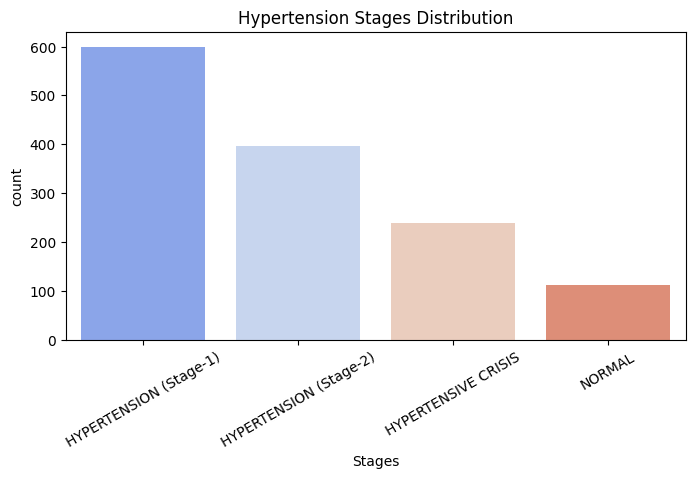

In [12]:
plt.figure(figsize=(8,4))
sns.countplot(data=data, x="Stages", palette="coolwarm")
plt.title("Hypertension Stages Distribution")
plt.xticks(rotation=30)
plt.show()

# **3. Correlation between Systolic and Diastolic Pressure**

A heatmap (Figure 4) was plotted to examine the relationship between the numeric representations of systolic and diastolic blood pressure (converted from categoricalranges to midpoints).
 The heatmap displayed a strong positive correlation between systolic and diastolic values, as expected in physiological data — indicating that as systolic pressure increases, diastolic pressure also tends to rise proportionally. This validates the integrity of the recorded measurements.

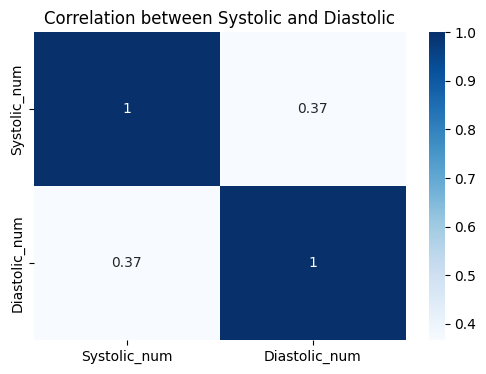

In [13]:
# Heatmap on encoded numeric BP only
import numpy as np
def range_to_midpoint(val):
  if "-" in val:
    start, end = val.split("-")
    return (int(start.strip()) + int(end.strip()))/2
  elif "+" in val:
    return int(val.replace("+","").strip())
  else:
    return np.nan

data['Systolic_num'] = data['Systolic'].apply(range_to_midpoint)
data['Diastolic_num'] = data['Diastolic'].apply(range_to_midpoint)

plt.figure(figsize=(6,4))
sns.heatmap(data[['Systolic_num','Diastolic_num']].corr(), annot=True, cmap="Blues")
plt.title("Correlation between Systolic and Diastolic")
plt.show()

# **4. TakeMedication vs. Severity**

A count plot (Figure 5) was created to explore the relationship between medication status and hypertension severity.
 The visualization showed that patients taking medication were predominantly in higher severity categories, whereas those not on medication were more frequent in lower stages or normal conditions. This trend implies a logical connection between treatment status and disease intensity.

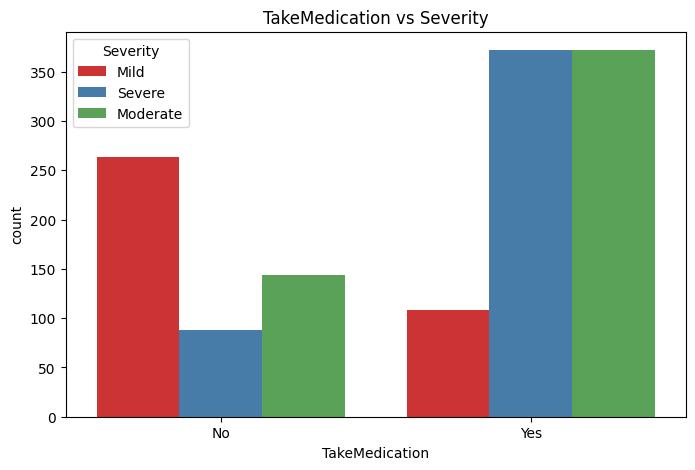

In [14]:
# Relationship: TakeMedication vs Severity
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="TakeMedication", hue="Severity", palette="Set1")
plt.title("TakeMedication vs Severity")
plt.show()

# **5. Age Group vs. Hypertension Stages**

Another count plot (Figure 6) was used to examine how age groups are distributed across different hypertension stages.
 The analysis revealed that middle-aged and elderly individuals had a higher prevalence of Stage-1 and Stage-2 hypertension compared to younger patients. This pattern aligns with medical expectations that hypertension risk increases with age, highlighting the importance of preventive screening for older populations.

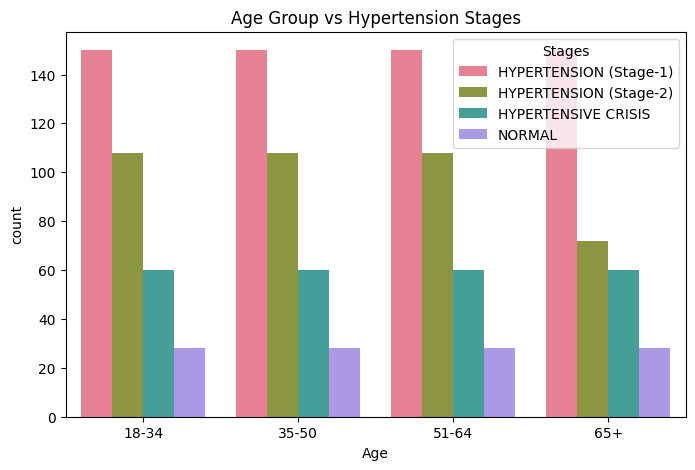

In [15]:
# Age group vs Stages
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="Age", hue="Stages", palette="husl")
plt.title("Age Group vs Hypertension Stages")
plt.show()

# **6. Pairplot: Systolic vs. Diastolic across Stages**

A pairplot (Figure 7) was generated to study the multivariate relationship between systolic and diastolic blood pressure across different hypertension stages.
 Distinct clusters were visible, indicating that patients with higher systolic and diastolic values tend to belong to higher hypertension stages. The distribution patterns across the diagonal density plots also confirmed increasing spread with disease severity, suggesting progressive blood pressure elevation as hypertension advances.



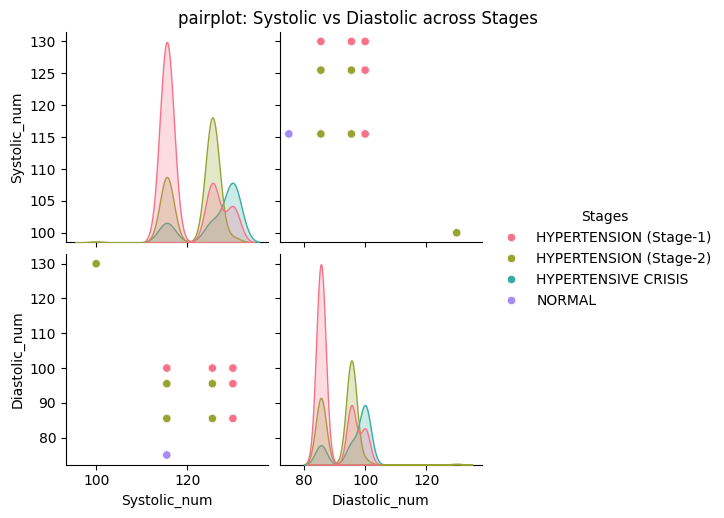

In [16]:
# Pairplot on numeric BP with Stages as hue
sns.pairplot(data[['Systolic_num','Diastolic_num','Stages']], hue='Stages', diag_kind='kde',palette="husl")
plt.suptitle("pairplot: Systolic vs Diastolic across Stages", y=1.02)
plt.show()

# **Encode nominal features**

In [17]:
# 4) Label Encoding
# Nominal Features
nominal_mapping = {'No': 0, 'Yes': 1}
for col in ['History', 'Patient', 'TakeMedication', 'BreathShortness', 'VisualChanges', 'NoseBleeding', 'ControlledDiet']:
    data[col] = data[col].map(nominal_mapping)

data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})

# Ordinal Features
data['Age'] = data['Age'].map({
    '18-34': 1, '18-34 years': 1,
    '35-50': 2, '35-44 years': 2, '45-54 years': 2,
    '51-64': 3, '55-64 years': 3,
    '65+': 4, '65+ years': 4
})

data['Severity'] = data['Severity'].map({'None': 0, 'Mild': 0, 'Moderate': 1, 'Severe': 2})

data['Whendiagnoused'] = data['Whendiagnoused'].map({
    'N/A': 0,
    '<1 Year': 1, 'Less than 1 Year': 1,
    '1-5 Years': 2,
    '>5 Years': 3, '5+ Years': 3
})

data['Systolic'] = data['Systolic'].map({
    '100 - 110': 0, 'Less than 120 mmHg (Normal)': 0,
    '111 - 120': 1, '120-129 mmHg (Elevated)': 1,
    '121 - 130': 2, '130-139 mmHg (Stage 1)': 2,
    '130+': 3, '140-180 mmHg (Stage 2)': 3, 'Higher than 180 mmHg (Crisis)': 3
})

data['Diastolic'] = data['Diastolic'].map({
    '70 - 80': 0, 'Less than 80 mmHg (Normal)': 0,
    '81 - 90': 1, '80-89 mmHg (Stage 1)': 1,
    '91 - 100': 2, '90-120 mmHg (Stage 2)': 2,
    '100+': 3, 'Higher than 120 mmHg (Crisis)': 3
})

# Target Variable
data['Stages'] = data['Stages'].map({
    'NORMAL': 0,
    'HYPERTENSION (Stage-1)': 1,
    'HYPERTENSION (Stage-2)': 2,
    'HYPERTENSIVE CRISIS': 3
})

# Drop any rows that failed to map (NaNs)
data = data.dropna()

# **Data Splitting**

In [18]:
print(data.isna().sum())

Gender             0
Age                0
History            0
Patient            0
TakeMedication     0
Severity           0
BreathShortness    0
VisualChanges      0
NoseBleeding       0
Whendiagnoused     0
Systolic           0
Diastolic          0
ControlledDiet     0
Stages             0
Systolic_num       0
Diastolic_num      0
dtype: int64


In [19]:
X = data.drop(['Stages'], axis=1)
# Drop numeric helper columns if they exist from previous notebook runs
if 'Systolic_num' in X.columns: X = X.drop(['Systolic_num'], axis=1)
if 'Diastolic_num' in X.columns: X = X.drop(['Diastolic_num'], axis=1)

y = data['Stages']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Check the number of rows (samples)
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# Or use .shape to see (rows, columns)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Training set size: 552
Testing set size: 138
X_train shape: (552, 13)
X_test shape: (138, 13)


In [21]:
# Detect all numeric columns automatically
numeric_features = X_train.select_dtypes(include=['int64','float64']).columns

print("Numeric features to scale:")
print(numeric_features)

Numeric features to scale:
Index(['Gender', 'Age', 'History', 'Patient', 'TakeMedication', 'Severity',
       'BreathShortness', 'VisualChanges', 'NoseBleeding', 'Whendiagnoused',
       'Systolic', 'Diastolic', 'ControlledDiet'],
      dtype='object')


## **Feature Scaling:** Applied MinMaxScaler to ordinal features for optimal model performance.

In [22]:
ordinal_cols = ['Age', 'Severity', 'Whendiagnoused', 'Systolic', 'Diastolic']
scaler = MinMaxScaler()
X_train[ordinal_cols] = scaler.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols] = scaler.transform(X_test[ordinal_cols])
print("Scaling completed successfully.")

Scaling completed successfully.


In [23]:
#Verify scaling worked
print(X_train[numeric_features].describe())

           Gender         Age     History     Patient  TakeMedication  \
count  552.000000  552.000000  552.000000  552.000000      552.000000   
mean     0.500000    0.496981    0.951087    0.416667        0.592391   
std      0.500454    0.374622    0.215882    0.493454        0.491835   
min      0.000000    0.000000    0.000000    0.000000        0.000000   
25%      0.000000    0.000000    1.000000    0.000000        0.000000   
50%      0.500000    0.666667    1.000000    0.000000        1.000000   
75%      1.000000    0.666667    1.000000    1.000000        1.000000   
max      1.000000    1.000000    1.000000    1.000000        1.000000   

         Severity  BreathShortness  VisualChanges  NoseBleeding  \
count  552.000000       552.000000     552.000000    552.000000   
mean     0.576087         0.509058       0.505435      0.375000   
std      0.368458         0.500371       0.500424      0.484562   
min      0.000000         0.000000       0.000000      0.000000   
25%    

# **Algorithm Implementation and Comparison**

In [24]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import cross_val_score

In [25]:
accuracy = {}

## **1. Logistic Regression**

In [26]:

# Initialize model
log_reg = LogisticRegression(max_iter=10000)

# Train model
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')

print("Logistic Regression Results:")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall: {rec*100:.2f}%")

Logistic Regression Results:
Accuracy: 93.48%
Precision: 93.52%
Recall: 93.48%


In [27]:
accuracy['Logistic Regression'] = acc *100

In [28]:
print(accuracy)

{'Logistic Regression': 93.47826086956522}


# **2.Decision Tree Classifier**

In [29]:
decisionTree = DecisionTreeClassifier()

decisionTree.fit(X_train, y_train)

y_pred = decisionTree.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Decision Tree Results:")
print(f"Accuracy: {acc*100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Decision Tree'] = acc * 100

Decision Tree Results:
Accuracy: 100.00%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        27

    accuracy                           1.00       138
   macro avg       1.00      1.00      1.00       138
weighted avg       1.00      1.00      1.00       138

Confusion Matrix:
 [[21  0  0  0]
 [ 0 57  0  0]
 [ 0  0 33  0]
 [ 0  0  0 27]]


In [30]:
print(accuracy)

{'Logistic Regression': 93.47826086956522, 'Decision Tree': 100.0}


# **3. Random Forest Classifier**

In [31]:
randomforest = RandomForestClassifier()

randomforest.fit(X_train, y_train)

y_pred = randomforest.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Random Forest Results:")
print(f"Accuracy: {acc*100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Random Forest'] = acc * 100

Random Forest Results:
Accuracy: 100.00%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        27

    accuracy                           1.00       138
   macro avg       1.00      1.00      1.00       138
weighted avg       1.00      1.00      1.00       138

Confusion Matrix:
 [[21  0  0  0]
 [ 0 57  0  0]
 [ 0  0 33  0]
 [ 0  0  0 27]]


In [32]:
print(accuracy)

{'Logistic Regression': 93.47826086956522, 'Decision Tree': 100.0, 'Random Forest': 100.0}


# **4. Support Vector Machine (SVM)**

In [33]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("SVM Results:")
print(f"Accuracy: {acc*100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['SVM'] = acc * 100

SVM Results:
Accuracy: 98.55%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        57
           2       0.94      1.00      0.97        33
           3       1.00      0.93      0.96        27

    accuracy                           0.99       138
   macro avg       0.99      0.98      0.98       138
weighted avg       0.99      0.99      0.99       138

Confusion Matrix:
 [[21  0  0  0]
 [ 0 57  0  0]
 [ 0  0 33  0]
 [ 0  0  2 25]]


In [34]:
print(accuracy)

{'Logistic Regression': 93.47826086956522, 'Decision Tree': 100.0, 'Random Forest': 100.0, 'SVM': 98.55072463768117}


# **5. K-Nearest Neighbors (KNN)**

In [35]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("KNN Results:")
print(f"Accuracy: {acc*100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['KNN'] = acc * 100

KNN Results:
Accuracy: 96.38%
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.86      0.90        21
           1       0.95      0.98      0.97        57
           2       0.97      1.00      0.99        33
           3       1.00      0.96      0.98        27

    accuracy                           0.96       138
   macro avg       0.97      0.95      0.96       138
weighted avg       0.96      0.96      0.96       138

Confusion Matrix:
 [[18  3  0  0]
 [ 1 56  0  0]
 [ 0  0 33  0]
 [ 0  0  1 26]]


In [36]:
print(accuracy)

{'Logistic Regression': 93.47826086956522, 'Decision Tree': 100.0, 'Random Forest': 100.0, 'SVM': 98.55072463768117, 'KNN': 96.37681159420289}


# **6. Ridge Classifier**

In [37]:
RC = RidgeClassifier()

RC.fit(X_train, y_train)

y_pred = RC.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Ridge Classifier Results:")
print(f"Accuracy: {acc*100:.2f}%")

accuracy['RidgeClassifier'] = acc * 100

Ridge Classifier Results:
Accuracy: 89.13%


In [38]:
print(accuracy)

{'Logistic Regression': 93.47826086956522, 'Decision Tree': 100.0, 'Random Forest': 100.0, 'SVM': 98.55072463768117, 'KNN': 96.37681159420289, 'RidgeClassifier': 89.13043478260869}


# **7. Gaussian Naive Bayes (Selected Model)**

In [39]:
naive_bayes = GaussianNB()

naive_bayes.fit(X_train, y_train)

y_pred = naive_bayes.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Naive Bayes Results:")
print(f"Accuracy: {acc*100:.2f}%")

accuracy['Naive Bayes'] = acc * 100

Naive Bayes Results:
Accuracy: 84.06%


In [40]:
print(accuracy)

{'Logistic Regression': 93.47826086956522, 'Decision Tree': 100.0, 'Random Forest': 100.0, 'SVM': 98.55072463768117, 'KNN': 96.37681159420289, 'RidgeClassifier': 89.13043478260869, 'Naive Bayes': 84.05797101449275}


In [41]:
print("Model Accuracy Comparison:")
for model, score in accuracy.items():
    print(f"{model}: {score:.2f}%")

Model Accuracy Comparison:
Logistic Regression: 93.48%
Decision Tree: 100.00%
Random Forest: 100.00%
SVM: 98.55%
KNN: 96.38%
RidgeClassifier: 89.13%
Naive Bayes: 84.06%


In [42]:
import joblib

# save model
joblib.dump(log_reg, "logreg_model.pkl")
print("Model saved as logreg_model.pkl")

Model saved as logreg_model.pkl
